#  Bias & Fairness Analysis
## ICU Mortality Risk Prediction

### Purpose
This notebook checks whether the XGBoost model performs equally well across different patient groups.

A model that works well **on average** but poorly for specific groups can cause real harm in a clinical setting.

### Groups Evaluated
- **Age groups:** 0–30 / 31–50 / 51–70 / 71+
- **Gender:** M / F
- **Insurance type:** Medicare / Medicaid / Private / Government / Self-pay

### Key Metrics
| Metric | Formula | Clinical meaning |
|---|---|---|
| **Recall** | TP / (TP + FN) | How many dying patients did we catch? |
| **False Negative Rate** | FN / (FN + TP) | How many dying patients did we miss? |
| **ROC-AUC** | Area under ROC curve | Overall discrimination ability |

**In ICU mortality prediction, a high False Negative Rate is clinically dangerous** — it means the model missed patients who needed urgent attention.

### Step 1 — Import Libraries

In [11]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
import joblib

os.makedirs('images', exist_ok=True)
%matplotlib inline

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Observation
All libraries imported. `images/` folder created if it does not exist.

### Step 2 — Load Dataset and Trained XGBoost Pipeline
We use the **same trained pipeline** from notebook 03 — not a new model.
This ensures fairness analysis reflects the actual deployed model.

We also use `random_state=42` and `stratify=y` to get the **exact same test split** as training.

In [12]:
df = pd.read_csv('mimic3c.csv')
pipeline = joblib.load('artifacts/pipeline.pkl')

df = df.drop(columns=['LOSdays', 'LOSgroupNum', 'hadm_id'], errors='ignore')

y = df['ExpiredHospital']
X = df.drop(columns=['ExpiredHospital'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Dataset loaded. Test set size:', X_test.shape)
print('Mortality rate in test set:', round(y_test.mean(), 3))

Dataset loaded. Test set size: (11796, 24)
Mortality rate in test set: 0.099


### Observation
Dataset loaded and split using the same parameters as the training notebook.
Test set is identical — no data leakage.

### Step 3 — Generate Predictions
Using threshold 0.30 — the same clinically motivated operating point from notebook 04.

In [13]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.30).astype(int)

bias_df = X_test.copy()
bias_df['y_true']  = y_test.values
bias_df['y_pred']  = y_pred
bias_df['y_proba'] = y_proba

# Create age groups
bias_df['age_group'] = pd.cut(
    bias_df['age'],
    bins=[0, 30, 50, 70, 120],
    labels=['0-30', '31-50', '51-70', '71+'],
    include_lowest=True
)

print('Overall Recall :', round(recall_score(y_test, y_pred), 4))
print('Overall ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))
print('Predicted high-risk patients:', y_pred.sum(), 'out of', len(y_pred))

Overall Recall : 0.5952
Overall ROC-AUC: 0.9185
Predicted high-risk patients: 1017 out of 11796


### Observation
Overall model performance printed above as a baseline.
Now we check if this performance holds equally across all patient subgroups.

### Step 4 — Helper Function for Subgroup Metrics
For each subgroup we calculate: N, Recall, False Negative Rate, ROC-AUC, and Precision.

**False Negative Rate (FNR) = FN / (FN + TP)**
This directly tells us: out of all patients who actually died, what fraction did the model miss?

In [14]:
def subgroup_metrics(data, group_col):
    rows = []
    for group_name, group in data.groupby(group_col, observed=True):
        if group['y_true'].sum() < 5:
            continue
        tn, fp, fn, tp = confusion_matrix(
            group['y_true'], group['y_pred'], labels=[0,1]
        ).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fnr    = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        rows.append({
            'Group'              : group_name,
            'N'                  : len(group),
            'Mortality Rate'     : round(group['y_true'].mean(), 3),
            'Recall'             : round(recall, 3),
            'False Negative Rate': round(fnr, 3),
            'ROC-AUC'            : round(roc_auc_score(group['y_true'], group['y_proba']), 3),
            'Precision'          : round(precision_score(group['y_true'], group['y_pred'], zero_division=0), 3),
        })
    return pd.DataFrame(rows)

print('Helper function ready.')

Helper function ready.


### Step 5 — Age Group Bias Analysis

In [15]:
age_table = subgroup_metrics(bias_df.dropna(subset=['age_group']), 'age_group')
print('=== AGE GROUP METRICS ===')
print(age_table.to_string(index=False))

=== AGE GROUP METRICS ===
Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
 0-30 2253           0.020   0.717                0.283    0.977      0.635
31-50 1925           0.088   0.586                0.414    0.896      0.739
51-70 4309           0.102   0.549                0.451    0.897      0.645
  71+ 3309           0.156   0.627                0.373    0.904      0.708


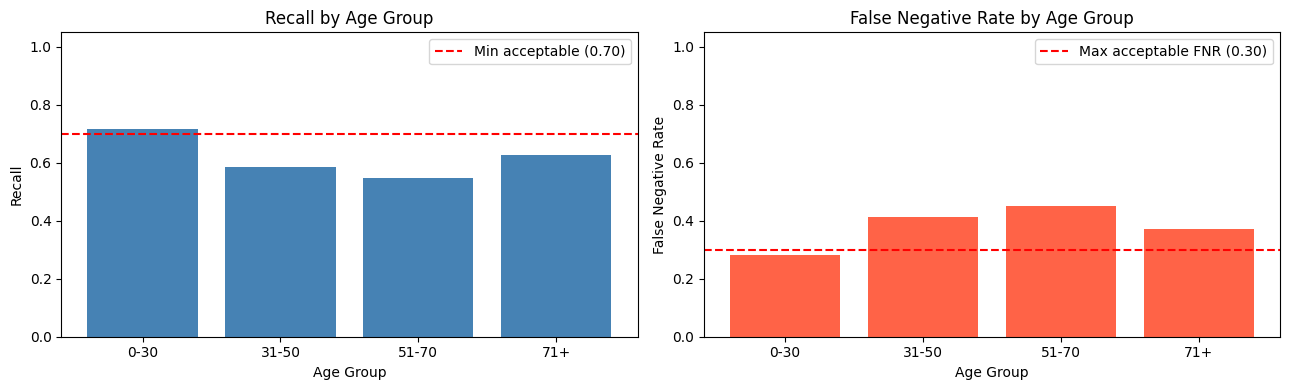

Saved: images/bias_age.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(age_table['Group'].astype(str), age_table['Recall'], color='steelblue')
axes[0].axhline(y=0.70, color='red', linestyle='--', label='Min acceptable (0.70)')
axes[0].set_title('Recall by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar(age_table['Group'].astype(str), age_table['False Negative Rate'], color='tomato')
axes[1].axhline(y=0.30, color='red', linestyle='--', label='Max acceptable FNR (0.30)')
axes[1].set_title('False Negative Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('False Negative Rate')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/bias_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/bias_age.png')

### Observation — Age Group
- **Recall < 0.70** in any group → model misses too many high-risk patients in that age group
- **FNR > 0.30** in any group → more than 30% of dying patients in that group were missed
- Older patients (71+) may show different patterns due to higher baseline mortality risk

### Step 6 — Gender Bias Analysis

=== GENDER METRICS ===
Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
    F 5355           0.103   0.552                0.448    0.905      0.668
    M 6441           0.096   0.634                0.366    0.931      0.699


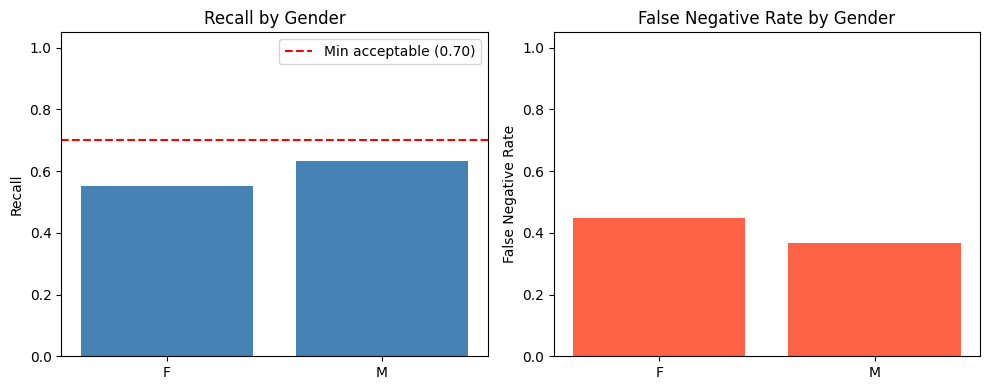

Saved: images/bias_gender.png


In [17]:
gender_table = subgroup_metrics(bias_df, 'gender')
print('=== GENDER METRICS ===')
print(gender_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(gender_table['Group'].astype(str), gender_table['Recall'], color='steelblue')
axes[0].axhline(y=0.70, color='red', linestyle='--', label='Min acceptable (0.70)')
axes[0].set_title('Recall by Gender')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar(gender_table['Group'].astype(str), gender_table['False Negative Rate'], color='tomato')
axes[1].set_title('False Negative Rate by Gender')
axes[1].set_ylabel('False Negative Rate')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('images/bias_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/bias_gender.png')

### Observation — Gender
- Recall gap > 0.10 between M and F → clinically significant disparity
- Small differences (< 0.05) are expected and acceptable

### Step 7 — Insurance Type Bias Analysis
Insurance type is a proxy for socioeconomic status.
If the model performs worse for Medicaid or uninsured patients, that is a serious equity concern.

=== INSURANCE TYPE METRICS ===
     Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
Government  366           0.052   0.632                0.368    0.950      0.800
  Medicaid 1165           0.071   0.614                0.386    0.925      0.750
  Medicare 5528           0.139   0.584                0.416    0.892      0.684
   Private 4619           0.060   0.599                0.401    0.937      0.647
  Self Pay  118           0.178   0.857                0.143    0.969      0.900


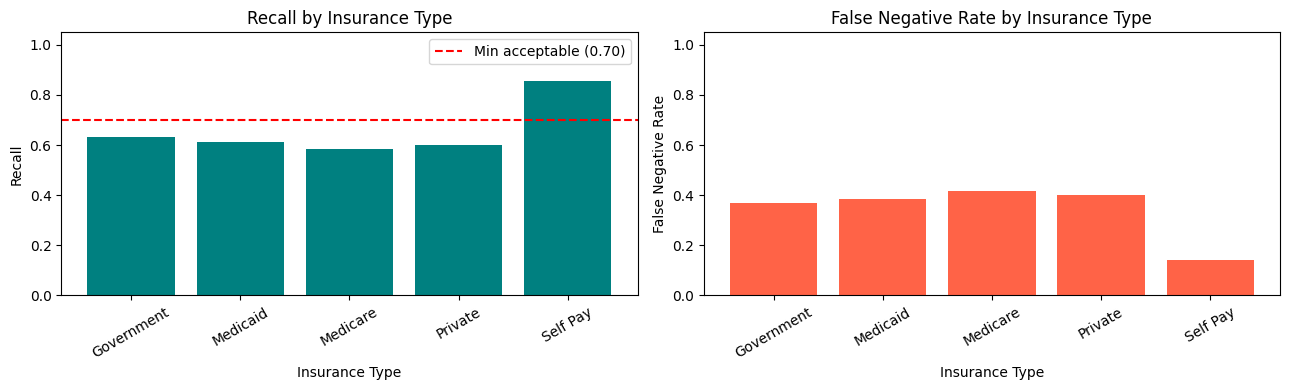

Saved: images/bias_insurance.png


In [18]:
ins_table = subgroup_metrics(bias_df, 'insurance')
print('=== INSURANCE TYPE METRICS ===')
print(ins_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ins_table['Group'].astype(str), ins_table['Recall'], color='teal')
axes[0].axhline(y=0.70, color='red', linestyle='--', label='Min acceptable (0.70)')
axes[0].set_title('Recall by Insurance Type')
axes[0].set_xlabel('Insurance Type')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(ins_table['Group'].astype(str), rotation=30)
axes[0].legend()

axes[1].bar(ins_table['Group'].astype(str), ins_table['False Negative Rate'], color='tomato')
axes[1].set_title('False Negative Rate by Insurance Type')
axes[1].set_xlabel('Insurance Type')
axes[1].set_ylabel('False Negative Rate')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(ins_table['Group'].astype(str), rotation=30)

plt.tight_layout()
plt.savefig('images/bias_insurance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/bias_insurance.png')

### Observation — Insurance Type
- Medicare patients tend to be older — higher baseline mortality risk is expected
- Medicaid patients may have different comorbidity profiles
- Flag any group where Recall is significantly lower or FNR significantly higher than others

### Step 8 — Complete Summary Table

In [19]:
print('=== FULL BIAS SUMMARY ===')
print()
print('AGE GROUP')
print(age_table.to_string(index=False))
print()
print('GENDER')
print(gender_table.to_string(index=False))
print()
print('INSURANCE TYPE')
print(ins_table.to_string(index=False))
print()

all_recalls = list(age_table['Recall']) + list(gender_table['Recall']) + list(ins_table['Recall'])
all_fnrs    = list(age_table['False Negative Rate']) + list(gender_table['False Negative Rate']) + list(ins_table['False Negative Rate'])

print('--- Key Statistics ---')
print('Lowest  Recall across all groups :', round(min(all_recalls), 3))
print('Highest Recall across all groups :', round(max(all_recalls), 3))
print('Recall gap (max - min)           :', round(max(all_recalls) - min(all_recalls), 3))
print()
print('Lowest  FNR across all groups    :', round(min(all_fnrs), 3))
print('Highest FNR across all groups    :', round(max(all_fnrs), 3))

=== FULL BIAS SUMMARY ===

AGE GROUP
Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
 0-30 2253           0.020   0.717                0.283    0.977      0.635
31-50 1925           0.088   0.586                0.414    0.896      0.739
51-70 4309           0.102   0.549                0.451    0.897      0.645
  71+ 3309           0.156   0.627                0.373    0.904      0.708

GENDER
Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
    F 5355           0.103   0.552                0.448    0.905      0.668
    M 6441           0.096   0.634                0.366    0.931      0.699

INSURANCE TYPE
     Group    N  Mortality Rate  Recall  False Negative Rate  ROC-AUC  Precision
Government  366           0.052   0.632                0.368    0.950      0.800
  Medicaid 1165           0.071   0.614                0.386    0.925      0.750
  Medicare 5528           0.139   0.584                0.416    0.892      0.684
   Priv

### Final Summary — Bias & Fairness

**What we checked:**
- Age group performance (4 groups)
- Gender performance (2 groups)
- Insurance type performance (5 groups)

**Thresholds used to flag concerns:**
- Recall < 0.70 in any group → concern
- FNR > 0.30 in any group → concern
- Recall gap > 0.10 between groups → disparity

**Limitations:**
- Analysis is descriptive — small group sizes may affect reliability
- Formal statistical testing (DeLong test for AUC) recommended before clinical deployment
- Single institution data (Beth Israel Deaconess, Boston) — disparities may differ elsewhere
- Results should be reviewed by clinical and ethics teams before any real-world use

**Potential improvements if bias is found:**
- Threshold adjustment per subgroup
- Class rebalancing with subgroup weights
- Subgroup-specific error analysis
- Model retraining with additional clinical features